In [1]:
import pandas as pd

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [3]:
def get_recalls_auc(path: Path):
    experiments: list[list] = load_experiment_metrics(path)
    recalls_auc: list[float] = []
    for experiment in experiments:
        recall_auc = AbstractContextualModel.calculate_partial_auc(experiment)
        recalls_auc.append(recall_auc)

    return recalls_auc

In [4]:
deep_autoencoder_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "deep_autoencoder_v3"

baseline_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v2"

In [5]:
deep_autoencoder_recalls, deep_autoencoder_precisions = get_precisions_recalls(deep_autoencoder_path)
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline_path)

In [6]:
deep_autoencoder_recalls_auc = get_recalls_auc(deep_autoencoder_path)
baseline_recalls_auc = get_recalls_auc(baseline_path)

In [7]:
np.array(deep_autoencoder_recalls_auc).mean(), np.array(baseline_recalls_auc).mean()

(np.float64(0.8977980596618349), np.float64(0.8937074946193079))

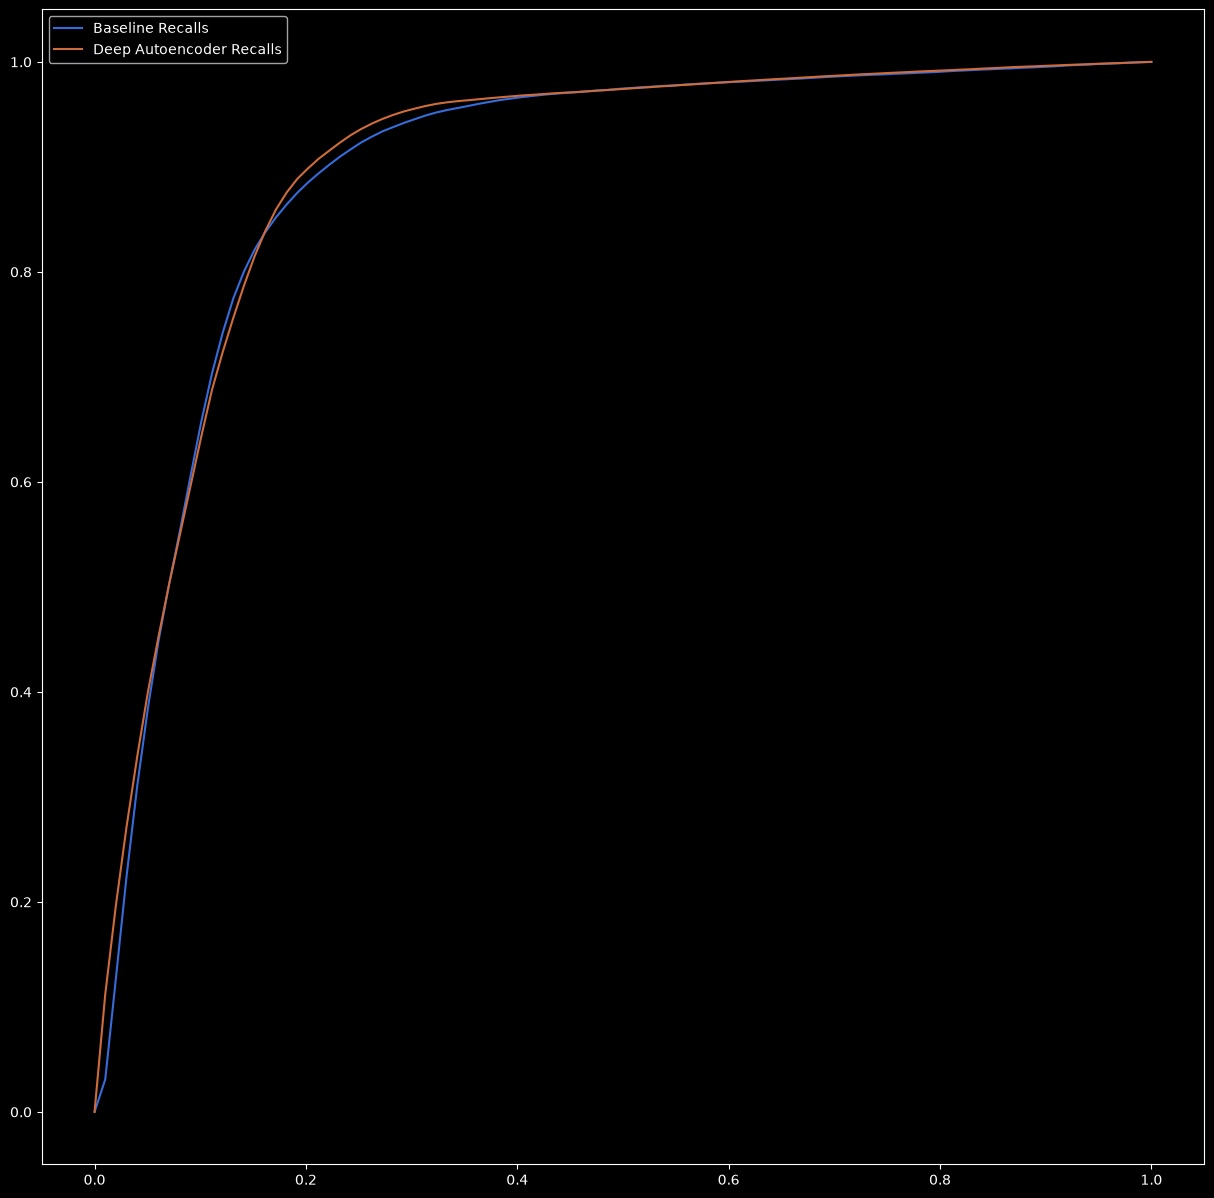

In [8]:
plt.figure(figsize=(15, 15))


plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0),
         label="Baseline Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(deep_autoencoder_recalls).mean(axis=0),
         label="Deep Autoencoder Recalls")

plt.legend()

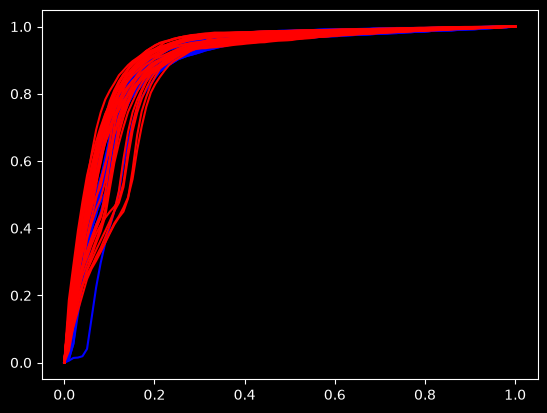

In [9]:



for i in range(30):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls)[i],
         label="Baseline Recalls", color ="blue")


for i in range(len(deep_autoencoder_recalls)):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(deep_autoencoder_recalls)[i],
         label="Deep Autoencoder Recalls", color ="red")

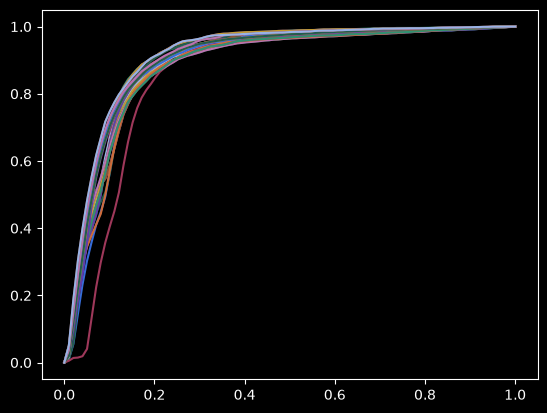

In [10]:
for i in range(30):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls)[i],
         label="Deep Autoencoder Recalls")

In [11]:
len(deep_autoencoder_recalls)

30

In [12]:
sae_experiments: list[list] = load_experiment_metrics(deep_autoencoder_path)

In [13]:
sae_s = []

for experiment in sae_experiments:
    sae_s += [metric.prediction for metric in experiment]

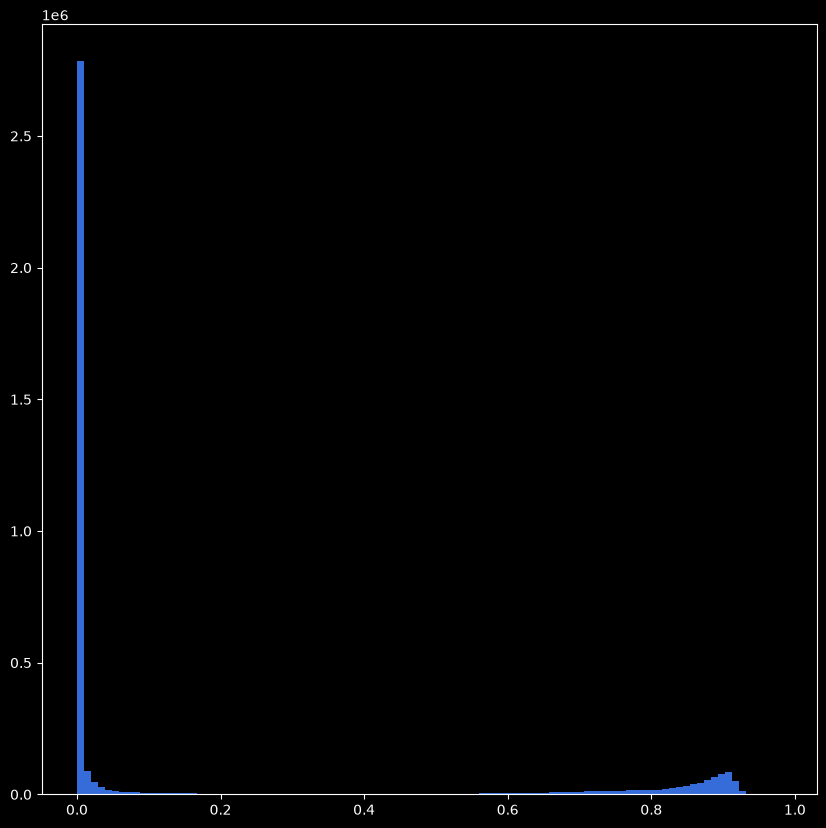

In [14]:
plt.figure(figsize=(10, 10))

plt.hist(sae_s, bins=100)
plt.show()

In [15]:
def delta_pct(lhs: np.ndarray, rhs: np.ndarray, decimals: int = 2 ) -> np.ndarray:
    return ((lhs-rhs)*100).round(decimals)

In [16]:
delta_pct(np.array(deep_autoencoder_recalls).mean(axis=0), np.array(baseline_recalls).mean(axis=0))

array([ 0.01,  8.1 ,  6.95,  4.72,  2.79,  1.55,  0.42, -0.01, -0.36,
       -0.95, -1.42, -1.56, -1.84, -1.85, -1.34, -0.63,  0.13,  0.76,
        1.14,  1.32,  1.34,  1.39,  1.35,  1.34,  1.35,  1.28,  1.24,
        1.18,  1.16,  1.09,  1.  ,  0.91,  0.82,  0.74,  0.66,  0.55,
        0.44,  0.35,  0.26,  0.21,  0.16,  0.11,  0.07,  0.04,  0.03,
        0.01, -0.  , -0.  , -0.01, -0.04, -0.03, -0.04, -0.04, -0.03,
       -0.03, -0.02, -0.02, -0.02, -0.01,  0.02,  0.03,  0.05,  0.05,
        0.07,  0.07,  0.07,  0.08,  0.08,  0.08,  0.07,  0.08,  0.08,
        0.09,  0.1 ,  0.11,  0.1 ,  0.12,  0.12,  0.12,  0.12,  0.1 ,
        0.09,  0.09,  0.09,  0.1 ,  0.1 ,  0.11,  0.09,  0.09,  0.09,
        0.07,  0.05,  0.04,  0.03,  0.02,  0.02,  0.01,  0.01,  0.01,
        0.  ])